<a href="https://colab.research.google.com/github/fernandapetty/data-analytics/blob/techchallenge3-covid19-arquitetura-medalhao-AWS/notebook-data-analizys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ======================================================
# PIPELINE PNAD-COVID — PySpark -> Parquet -> GCS -> BigQuery
# Projeto: tech3-471514 | Bucket: pnad-covid-bucket-tech3
# ======================================================

# 1) Ambiente
!apt-get -qq update
!apt-get -qq install -y openjdk-17-jdk-headless
!pip -q install pyspark==3.5.1 google-cloud-bigquery

import os, tarfile, urllib.request, shutil

PROJECT_ID = "tech3-471514"
BUCKET = "pnad-covid-bucket-tech3"
DATASET_BQ = "pnad_covid"          # dataset final
TMP_DATASET = "tmp_pnad"           # mantemos criado (não será usado no load)
MESES_DESEJADOS = ["05","07","09"] # meses alvo (ajusta automático se faltar)

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] += f":{os.environ['JAVA_HOME']}/bin"
os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID

# 2) Autenticação e datasets
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
bq = bigquery.Client(project=PROJECT_ID)
for ds in [DATASET_BQ, TMP_DATASET]:
    bq.create_dataset(f"{PROJECT_ID}.{ds}", exists_ok=True)
print(f"✅ Datasets prontos: {PROJECT_ID}.{DATASET_BQ} e {PROJECT_ID}.{TMP_DATASET}")

# 3) Trazer CSVs do GCS para o Colab
!mkdir -p /content/pnad_raw
print(f"📂 Listando no bucket:")
!gsutil ls gs://$BUCKET/raw/*.csv || echo "⚠️ Nenhum CSV listado em gs://$BUCKET/raw/"
print("⬇️ Copiando para /content/pnad_raw ...")
!gsutil -m cp gs://$BUCKET/raw/*.csv /content/pnad_raw/ || echo "⚠️ Falha ao copiar."
print("📁 Arquivos locais:")
!ls -lh /content/pnad_raw | head -n 50

# 4) Iniciar Spark (sem conector BigQuery; vamos usar BigQuery Client depois)
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("pnad-covid-spark").getOrCreate()
print("✅ Spark iniciado.")

# 5) Ler CSV local + limpeza + mapeamentos
from pyspark.sql.functions import input_file_name, regexp_extract, col, when, create_map, lit, mean, count, asc
from itertools import chain

input_path_local = "file:///content/pnad_raw/*.csv"
df_raw = (
    spark.read
    .option("header", True)
    .option("encoding", "ISO-8859-1")
    .option("inferSchema", True)
    .csv(input_path_local)
)

print("🧾 Schema lido:")
df_raw.printSchema()

df_src = df_raw.withColumn("_src", input_file_name())
print("📌 Arquivos lidos (até 10):")
df_src.select("_src").distinct().show(10, truncate=False)

# Extrai MES de nomes tipo ..._052020.csv  -> "05"
df = df_src.withColumn("MES", regexp_extract(col("_src"), r"_(\d{2})(?=\d{4})", 1))

cols_keep = [
    "UF","V2007","V2009","V2010",     # Demográficas
    "B0011","B0012","B0013","B0014",  # Sintomas
    "B002","C001",                    # Comportamento/teste
    "D0013",                          # Econômico
    "MES"
]
cols_keep = [c for c in cols_keep if c in df.columns]
df = df.select(*cols_keep)
print(f"🧮 Colunas selecionadas ({len(cols_keep)}): {cols_keep}")

map_sim_nao = {1: "Sim", 2: "Não", 9: "Não sabe"}
map_ficou   = {1: "Sempre", 2: "Quase sempre", 3: "Às vezes", 4: "Raramente", 5: "Nunca", 9: "Não sabe"}
def dict_to_map(d): return create_map([lit(x) for x in chain(*d.items())])
m_simnao, m_ficou = dict_to_map(map_sim_nao), dict_to_map(map_ficou)

sint_map = {"B0011":"FEBRE","B0012":"TOSSE","B0013":"DOR_GARGANTA","B0014":"DIFICULDADE_RESPIRAR"}
df_clean = df
for k,v in sint_map.items():
    if k in df_clean.columns:
        df_clean = df_clean.withColumn(v, m_simnao.getItem(col(k).cast("int")))
if "C001" in df_clean.columns:
    df_clean = df_clean.withColumn("FICOU_EM_CASA", m_ficou.getItem(col("C001").cast("int")))
if "B002" in df_clean.columns:
    df_clean = df_clean.withColumn("TESTE_COVID", m_simnao.getItem(col("B002").cast("int")))
if "D0013" in df_clean.columns:
    df_clean = df_clean.withColumn("PERDA_RENDA", m_simnao.getItem(col("D0013").cast("int")))

print("✅ Limpeza + mapeamentos concluídos.")

# 6) Seleção automática de 3 meses (usa desejados; se faltar, escolhe o mais próximo disponível)
disp_rows = df.select("MES").distinct().orderBy(asc("MES")).collect()
MESES_DISPONIVEIS = [r["MES"] for r in disp_rows if r["MES"]]
print("🗓️ Meses detectados:", MESES_DISPONIVEIS)

def escolher_3_meses(desejados, disponiveis):
    desejados = [m for m in desejados if m]
    disp = [m for m in disponiveis if m]
    usados = []
    for m in desejados:
        if m in disp and m not in usados:
            usados.append(m)
    def prox(target, pool): return sorted(pool, key=lambda x: abs(int(x)-int(target)))
    for m in desejados:
        if len(usados)>=3: break
        if m not in usados and disp:
            cand = [x for x in disp if x not in usados]
            if cand: usados.append(prox(m, cand)[0])
    for x in disp:
        if len(usados)>=3: break
        if x not in usados: usados.append(x)
    return usados[:3]

MESES_USO = escolher_3_meses(MESES_DESEJADOS, MESES_DISPONIVEIS)
print(f"🎯 Meses desejados: {MESES_DESEJADOS} | Meses usados: {MESES_USO}")

df_3m = df_clean.filter(col("MES").isin(MESES_USO))
print("📈 Contagem por MES (usados):")
df_3m.groupBy("MES").agg(count("*").alias("qtde")).orderBy("MES").show()
print("🔢 Total:", df_3m.count())

print("📌 Arquivos realmente usados (até 50):")
df_3m.select(input_file_name().alias("src")).distinct().show(50, truncate=False)

print("👀 Amostra (5 linhas):")
df_3m.limit(5).show(truncate=False)

# 7) Agregação: prevalência de sintomas por UF (proporção de 'Sim')
sym_cols = [c for c in ["FEBRE","TOSSE","DOR_GARGANTA","DIFICULDADE_RESPIRAR"] if c in df_3m.columns]
exprs = [mean(when(col(c)=="Sim",1).otherwise(0)).alias(f"prop_{c}") for c in sym_cols]
prev_uf_3m = df_3m.groupBy("UF").agg(*exprs)
print("📊 Prevalência por UF:")
prev_uf_3m.show(30, truncate=False)

# 8) Salvar em PARQUET local e subir pro GCS
LOCAL_DIR = "/content/pnad_out"
GCS_STAGING = f"gs://{BUCKET}/staging"
!rm -rf $LOCAL_DIR
!mkdir -p $LOCAL_DIR

df_3m.write.mode("overwrite").parquet(f"file://{LOCAL_DIR}/pnad_curado_3meses")
prev_uf_3m.write.mode("overwrite").parquet(f"file://{LOCAL_DIR}/prev_sintomas_uf_3meses")

print("⬆️ Enviando Parquet para o GCS (staging)...")
!gsutil -m rsync -r $LOCAL_DIR gs://$BUCKET/staging

# 9) Carregar no BigQuery a partir do GCS (formato PARQUET)
from google.cloud import bigquery
job_cfg = bigquery.LoadJobConfig(source_format=bigquery.SourceFormat.PARQUET, write_disposition="WRITE_TRUNCATE")

uris = {
    "pnad_curado_3meses":      f"{GCS_STAGING}/pnad_curado_3meses/*.parquet",
    "prev_sintomas_uf_3meses": f"{GCS_STAGING}/prev_sintomas_uf_3meses/*.parquet",
}

for table, uri in uris.items():
    table_id = f"{PROJECT_ID}.{DATASET_BQ}.{table}"
    job = bq.load_table_from_uri(uri, table_id, job_config=job_cfg)
    print(f"⏳ Carregando {table} do {uri} -> {table_id} ...")
    job.result()
    print(f"✅ BigQuery OK: {table_id}")

# 10) Validação com consultas no BigQuery (sem conector Spark)
def preview(table, limit=5):
    print(f"\n🔎 Prévia de `{PROJECT_ID}.{DATASET_BQ}.{table}` (primeiras {limit}):")
    q = f"SELECT * FROM `{PROJECT_ID}.{DATASET_BQ}.{table}` LIMIT {limit}"
    rows = list(bq.query(q).result())
    if not rows:
        print("(sem linhas)")
    else:
        for r in rows:
            print(dict(r))
    total = list(bq.query(f"SELECT COUNT(*) c FROM `{PROJECT_ID}.{DATASET_BQ}.{table}`").result())[0]["c"]
    print(f"📊 Total de linhas: {total:,}")

def meses_tabela():
    print(f"\n🗓️ Meses em `{PROJECT_ID}.{DATASET_BQ}.pnad_curado_3meses`:")
    q = f"""
      SELECT MES, COUNT(*) qtde
      FROM `{PROJECT_ID}.{DATASET_BQ}.pnad_curado_3meses`
      GROUP BY MES
      ORDER BY MES
    """
    for r in bq.query(q).result():
        print(dict(r))

preview("pnad_curado_3meses", 5)
meses_tabela()
preview("prev_sintomas_uf_3meses", 10)

print("\n✅ FIM: PySpark -> Parquet -> GCS -> BigQuery + validação concluída.")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
✅ Datasets prontos: tech3-471514.pnad_covid e tech3-471514.tmp_pnad
📂 Listando no bucket:
gs://pnad-covid-bucket-tech3/raw/PNAD_COVID_052020.csv
gs://pnad-covid-bucket-tech3/raw/PNAD_COVID_072020.csv
gs://pnad-covid-bucket-tech3/raw/PNAD_COVID_102020.csv
⬇️ Copiando para /content/pnad_raw ...
Copying gs://pnad-covid-bucket-tech3/raw/PNAD_COVID_072020.csv...
Copying gs://pnad-covid-bucket-tech3/raw/PNAD_COVID_052020.csv...
Copying gs://pnad-covid-bucket-tech3/raw/PNAD_COVID_102020.csv...
\ [3/3 files][301.4 MiB/301.4 MiB] 100% Done                                    
Operation completed over 3 objects/301.4 MiB.                                    
📁 Arquivos locais:
total 302M
-rw-r--r-- 1 root root  84M Sep  9 20:22 PNAD_COVID_052020.csv
-rw-r--r-- 1 root root 110M Sep  9 20:22 PNAD_COVID_072020.csv


🔎 Verificando tabelas no BigQuery...
  ✅ tech3-471514.pnad_covid.pnad_curado_3meses — 3341799 linhas, 16 colunas
  ✅ tech3-471514.pnad_covid.prev_sintomas_uf_3meses — 81 linhas, 5 colunas

📊 Registros por MES (garante os 3 meses usados):
MES    qtde
 05 1047918
 07 1152498
 10 1141383

🔥 Top 10 UFs por prevalência de FEBRE:
UF  prop_febre
16    0.065580
13    0.047156
15    0.047116
12    0.041346
14    0.040407
21    0.032307
23    0.032246
25    0.030617
11    0.028616
53    0.026175

🏠 Distribuição do isolamento (FICOU_EM_CASA):
 FICOU_EM_CASA     qtd  proporcao
        Sempre 1221828   0.365620
  Quase sempre 1078950   0.322865
Sem informação 1041021   0.311515

🛠️ Criando/atualizando VIEW: tech3-471514.pnad_covid.vw_prev_sintomas_uf
  ✅ VIEW pronta!

📈 Gráfico: Prevalência de FEBRE por UF (top 15)


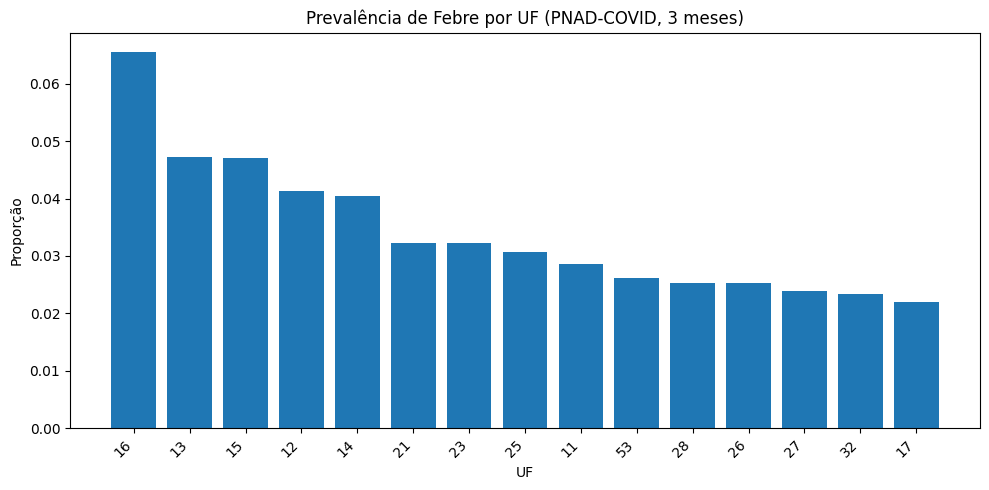


✅ Pronto! Tabelas validadas, VIEW criada e gráfico gerado.
   Dica: no Looker Studio, conecte no BigQuery e use a VIEW `tech3-471514.pnad_covid.vw_prev_sintomas_uf` pra montar seu dashboard.


In [ ]:
# ============================
# PRÓXIMOS PASSOS – TUDO JUNTO
# ============================
!pip -q install google-cloud-bigquery pandas matplotlib

from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
PROJECT_ID = "tech3-471514"
DATASET_BQ = "pnad_covid"
TABLE_RAW  = f"{PROJECT_ID}.{DATASET_BQ}.pnad_curado_3meses"
TABLE_AGG  = f"{PROJECT_ID}.{DATASET_BQ}.prev_sintomas_uf_3meses"
VIEW_NAME  = f"{PROJECT_ID}.{DATASET_BQ}.vw_prev_sintomas_uf"

bq = bigquery.Client(project=PROJECT_ID)

def qdf(sql: str) -> pd.DataFrame:
    return bq.query(sql).to_dataframe()

# 1) Validação rápida das tabelas
print("🔎 Verificando tabelas no BigQuery...")
for tb in [TABLE_RAW, TABLE_AGG]:
    try:
        meta = bq.get_table(tb)
        print(f"  ✅ {tb} — {meta.num_rows} linhas, {len(meta.schema)} colunas")
    except Exception as e:
        print(f"  ❌ {tb} — não encontrada: {e}")

# 2) Consultas úteis
print("\n📊 Registros por MES (garante os 3 meses usados):")
df_mes = qdf(f"""
    SELECT MES, COUNT(*) AS qtde
    FROM `{TABLE_RAW}`
    GROUP BY MES
    ORDER BY MES
""")
print(df_mes.to_string(index=False))

print("\n🔥 Top 10 UFs por prevalência de FEBRE:")
df_top_febre = qdf(f"""
    SELECT
      UF,
      AVG(CASE WHEN FEBRE = 'Sim' THEN 1 ELSE 0 END) AS prop_febre
    FROM `{TABLE_RAW}`
    GROUP BY UF
    ORDER BY prop_febre DESC
    LIMIT 10
""")
print(df_top_febre.to_string(index=False))

print("\n🏠 Distribuição do isolamento (FICOU_EM_CASA):")
df_isol = qdf(f"""
    SELECT
      COALESCE(FICOU_EM_CASA,'Sem informação') AS FICOU_EM_CASA,
      COUNT(*) AS qtd,
      COUNT(*) / SUM(COUNT(*)) OVER () AS proporcao
    FROM `{TABLE_RAW}`
    GROUP BY FICOU_EM_CASA
    ORDER BY proporcao DESC
""")
print(df_isol.to_string(index=False))

# 3) Criar/atualizar VIEW consolidada (boa pra dashboards)
print(f"\n🛠️ Criando/atualizando VIEW: {VIEW_NAME}")
bq.query(f"""
CREATE OR REPLACE VIEW `{VIEW_NAME}` AS
SELECT
  UF,
  AVG(CASE WHEN FEBRE='Sim' THEN 1 ELSE 0 END) AS prop_febre,
  AVG(CASE WHEN TOSSE='Sim' THEN 1 ELSE 0 END) AS prop_tosse,
  AVG(CASE WHEN DOR_GARGANTA='Sim' THEN 1 ELSE 0 END) AS prop_dor_garganta,
  AVG(CASE WHEN DIFICULDADE_RESPIRAR='Sim' THEN 1 ELSE 0 END) AS prop_dif_respirar
FROM `{TABLE_RAW}`
GROUP BY UF
""").result()
print("  ✅ VIEW pronta!")

# 4) Gráfico rápido no Colab (Febre por UF)
print("\n📈 Gráfico: Prevalência de FEBRE por UF (top 15)")
df_chart = qdf(f"""
    SELECT
      UF,
      AVG(CASE WHEN FEBRE='Sim' THEN 1 ELSE 0 END) AS prop_febre
    FROM `{TABLE_RAW}`
    GROUP BY UF
    ORDER BY prop_febre DESC
    LIMIT 15
""")

plt.figure(figsize=(10,5))
plt.bar(df_chart["UF"], df_chart["prop_febre"])
plt.title("Prevalência de Febre por UF (PNAD-COVID, 3 meses)")
plt.ylabel("Proporção")
plt.xlabel("UF")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\n✅ Pronto! Tabelas validadas, VIEW criada e gráfico gerado.")
print("   Dica: no Looker Studio, conecte no BigQuery e use a VIEW "
      f"`{VIEW_NAME}` pra montar seu dashboard.")


#**Antigo**

In [ ]:
import pandas as pd
import os

def carregar_pnad_corrigido(pasta):
    arquivos = [f for f in os.listdir(pasta) if f.endswith('.csv')]
    dfs = []

    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)
        mes = arquivo.split('_')[2][:2]  # Extrai o mês (05, 07, etc.)

        # Passo 1: Ler a primeira linha para obter os nomes das colunas
        with open(caminho, 'r', encoding='latin-1') as f:
            primeira_linha = f.readline().strip()
            colunas = primeira_linha.split(',')

        # Passo 2: Ler os dados com os nomes de colunas corretos
        df = pd.read_csv(
            caminho,
            sep=',',  # O separador real é vírgula
            encoding='latin-1',
            skiprows=1,  # Pula a linha de cabeçalho que já lemos
            names=colunas,  # Usa os nomes extraídos
            dtype={'V2007': 'int8', 'V2009': 'int8', 'UF': 'category'},
            usecols=lambda x: x in [
                'UF', 'V2007', 'V2009', 'V2010',  # Demográficas
                'B0011', 'B0012', 'B0013', 'B0014',  # Sintomas
                'B002', 'C001',  # Comportamento
                'D0013'  # Econômico
            ]
        )

        df['MES'] = mes
        dfs.append(df)
        print(f"✅ {arquivo} carregado | Colunas: {len(df.columns)}")

    return pd.concat(dfs, ignore_index=True)

# Carrega os dados
df_final = carregar_pnad_corrigido('/content/content')
print(f"\nTotal de registros: {len(df_final)}")
display(df_final.head())

✅ PNAD_COVID_052020.csv carregado | Colunas: 9
✅ PNAD_COVID_072020.csv carregado | Colunas: 9
✅ PNAD_COVID_102020.csv carregado | Colunas: 9

Total de registros: 635857


,UF,B0011,B0012,B0013,B0014,B002,C001,D0013,MES
0,11,1.0,1.0,2.0,2.0,2.0,1.0,NaN,05
1,11,1.0,1.0,2.0,2.0,2.0,1.0,NaN,05
2,11,2.0,2.0,2.0,2.0,NaN,NaN,NaN,05
3,11,2.0,2.0,2.0,2.0,NaN,NaN,NaN,05
4,11,2.0,2.0,2.0,2.0,NaN,2.0,NaN,05


In [ ]:
print("Colunas realmente disponíveis no DataFrame:")
print(df_final.columns.tolist())

Colunas realmente disponíveis no DataFrame:
['UF', 'B0011', 'B0012', 'B0013', 'B0014', 'B002', 'C001', 'D0013', 'MES']


✅ Pré-processamento concluído!


,UF,B0011,B0012,B0013,B0014,B002,C001,D0013,MES,FEBRE,TOSSE,DOR_GARGANTA,DIFICULDADE_RESPIRAR,FICOU_EM_CASA,TESTE_COVID,PERDA_RENDA
0,11,1.0,1.0,2.0,2.0,2.0,1.0,NaN,05,Sim,Sim,Não,Não,Sempre,Não,NaN
1,11,1.0,1.0,2.0,2.0,2.0,1.0,NaN,05,Sim,Sim,Não,Não,Sempre,Não,NaN
2,11,2.0,2.0,2.0,2.0,NaN,NaN,NaN,05,Não,Não,Não,Não,NaN,NaN,NaN
3,11,2.0,2.0,2.0,2.0,NaN,NaN,NaN,05,Não,Não,Não,Não,NaN,NaN,NaN
4,11,2.0,2.0,2.0,2.0,NaN,2.0,NaN,05,Não,Não,Não,Não,Quase sempre,NaN,NaN



📊 ANÁLISE DOS DADOS DISPONÍVEIS


<Figure size 1200x600 with 0 Axes>

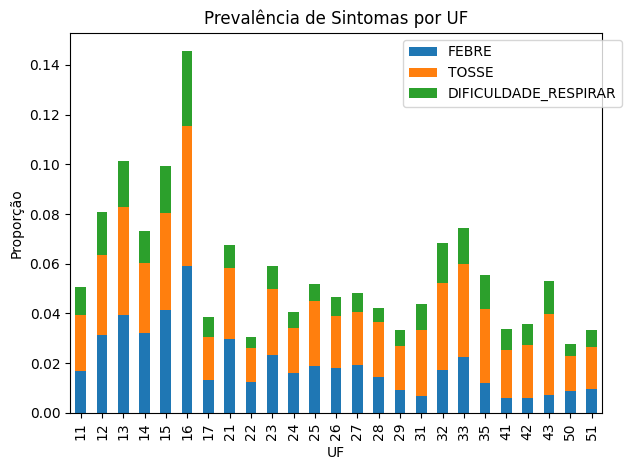


Comportamento de Isolamento:
FICOU_EM_CASA
Quase sempre    0.622701
Sempre          0.377299
Name: proportion, dtype: float64


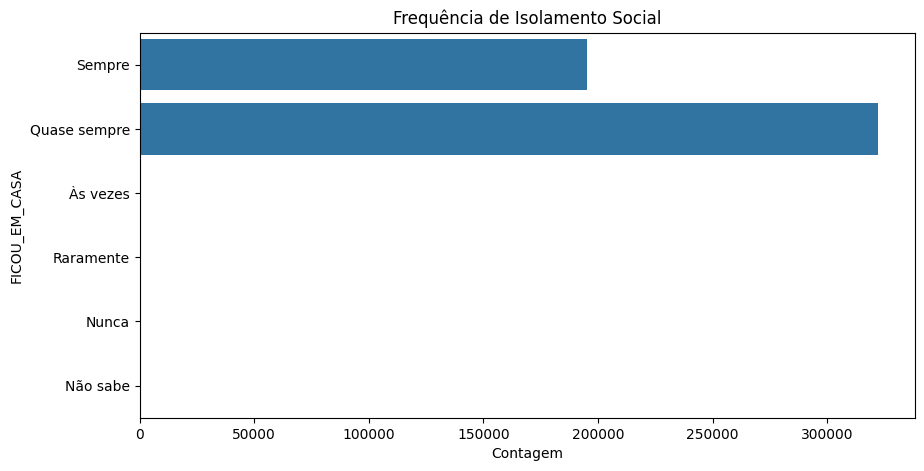

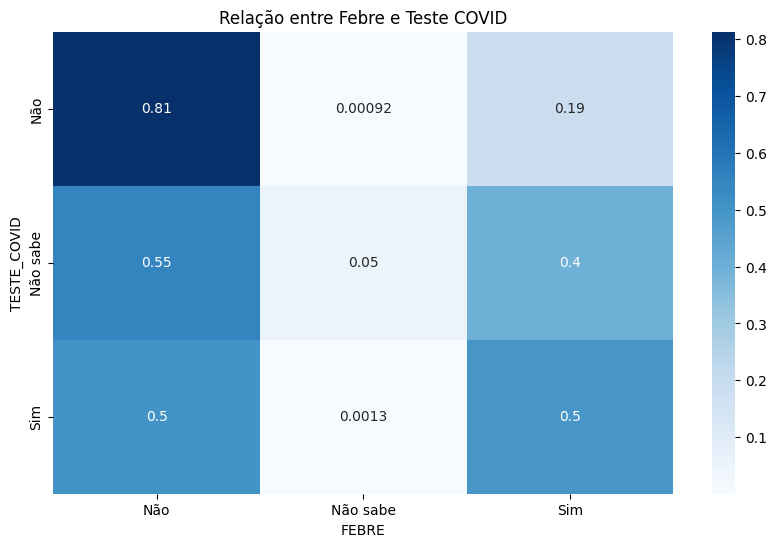


💡 RECOMENDAÇÕES BASEADAS NOS DADOS:
1. Priorizar protocolos para 'TOSSE' (prevalência: 2.7%)
2. Apenas 81.3% da população manteve isolamento adequado - considerar campanhas de conscientização
3. 0.0% reportaram perda de renda - sugerir políticas de apoio econômico


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dicionário de mapeamento (baseado no PNAD-COVID)
map_sim_nao = {1: 'Sim', 2: 'Não', 9: 'Não sabe'}
map_ficou_em_casa = {
    1: 'Sempre',
    2: 'Quase sempre',
    3: 'Às vezes',
    4: 'Raramente',
    5: 'Nunca',
    9: 'Não sabe'
}

# 2. Pré-processamento adaptado
def preprocess_pnad_adaptado(df):
    df_clean = df.copy()

    # Sintomas (mapeia apenas as colunas disponíveis)
    sintomas = {
        'B0011': 'FEBRE',
        'B0012': 'TOSSE',
        'B0013': 'DOR_GARGANTA',
        'B0014': 'DIFICULDADE_RESPIRAR'
    }

    for col, nome in sintomas.items():
        if col in df.columns:
            df_clean[nome] = df[col].map(map_sim_nao)

    # Comportamento e economia
    if 'C001' in df.columns:
        df_clean['FICOU_EM_CASA'] = df['C001'].map(map_ficou_em_casa)

    if 'B002' in df.columns:
        df_clean['TESTE_COVID'] = df['B002'].map(map_sim_nao)

    if 'D0013' in df.columns:
        df_clean['PERDA_RENDA'] = df['D0013'].map(map_sim_nao)

    return df_clean

# Processa os dados
df_clean = preprocess_pnad_adaptado(df_final)
print("✅ Pré-processamento concluído!")
display(df_clean.head())

# 3. Análise com as colunas disponíveis
print("\n📊 ANÁLISE DOS DADOS DISPONÍVEIS")

# A. Prevalência de sintomas por UF
plt.figure(figsize=(12, 6))
sintomas_uf = df_clean.groupby('UF')[['FEBRE', 'TOSSE', 'DIFICULDADE_RESPIRAR']].apply(lambda x: x.eq('Sim').mean())
sintomas_uf.plot(kind='bar', stacked=True)
plt.title('Prevalência de Sintomas por UF')
plt.ylabel('Proporção')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# B. Comportamento de isolamento
print("\nComportamento de Isolamento:")
print(df_clean['FICOU_EM_CASA'].value_counts(normalize=True).sort_index())

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, y='FICOU_EM_CASA', order=map_ficou_em_casa.values())
plt.title('Frequência de Isolamento Social')
plt.xlabel('Contagem')
plt.show()

# C. Relação entre sintomas e teste COVID
if 'TESTE_COVID' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pd.crosstab(
            df_clean['TESTE_COVID'],
            df_clean['FEBRE'],
            normalize='index'
        ),
        annot=True,
        cmap='Blues'
    )
    plt.title('Relação entre Febre e Teste COVID')
    plt.show()

# 4. Recomendações para o hospital
print("\n💡 RECOMENDAÇÕES BASEADAS NOS DADOS:")

# 1. Sintomas mais comuns
sintomas_prevalencia = df_clean[['FEBRE', 'TOSSE', 'DOR_GARGANTA', 'DIFICULDADE_RESPIRAR']].apply(lambda x: x.eq('Sim').mean())
top_sintoma = sintomas_prevalencia.idxmax()
print(f"1. Priorizar protocolos para '{top_sintoma}' (prevalência: {sintomas_prevalencia.max():.1%})")

# 2. Isolamento social
isolamento_adequado = (df_clean['FICOU_EM_CASA'].isin(['Sempre', 'Quase sempre'])).mean()
print(f"2. Apenas {isolamento_adequado:.1%} da população manteve isolamento adequado - considerar campanhas de conscientização")

# 3. Perda de renda
if 'PERDA_RENDA' in df_clean.columns:
    perda_renda = (df_clean['PERDA_RENDA'] == 'Sim').mean()
    print(f"3. {perda_renda:.1%} reportaram perda de renda - sugerir políticas de apoio econômico")


🔍 DADOS DISPONÍVEIS PARA ANÁLISE:


,UF,B0011,B0012,B0013,B0014,B002,C001,D0013,MES,FEBRE,TOSSE,DOR_GARGANTA,DIFICULDADE_RESPIRAR,FICOU_EM_CASA,TESTE_COVID,PERDA_RENDA
0,11,1.0,1.0,2.0,2.0,2.0,1.0,NaN,05,Sim,Sim,Não,Não,Sempre,Não,NaN
1,11,1.0,1.0,2.0,2.0,2.0,1.0,NaN,05,Sim,Sim,Não,Não,Sempre,Não,NaN
2,11,2.0,2.0,2.0,2.0,NaN,NaN,NaN,05,Não,Não,Não,Não,NaN,NaN,NaN
3,11,2.0,2.0,2.0,2.0,NaN,NaN,NaN,05,Não,Não,Não,Não,NaN,NaN,NaN
4,11,2.0,2.0,2.0,2.0,NaN,2.0,NaN,05,Não,Não,Não,Não,Quase sempre,NaN,NaN



📉 TAXA DE DADOS FALTANTES:


,Percentual Faltante
PERDA_RENDA,1.000000
B002,0.917898
TESTE_COVID,0.917898
D0013,0.670619
C001,0.186847
FICOU_EM_CASA,0.186847
DOR_GARGANTA,0.001411
DIFICULDADE_RESPIRAR,0.001345
FEBRE,0.001277
TOSSE,0.001274



🤒 PREVALÊNCIA DE SINTOMAS:


,Prevalência
FEBRE,0.019935
TOSSE,0.026588
DOR_GARGANTA,0.021137
DIFICULDADE_RESPIRAR,0.010551


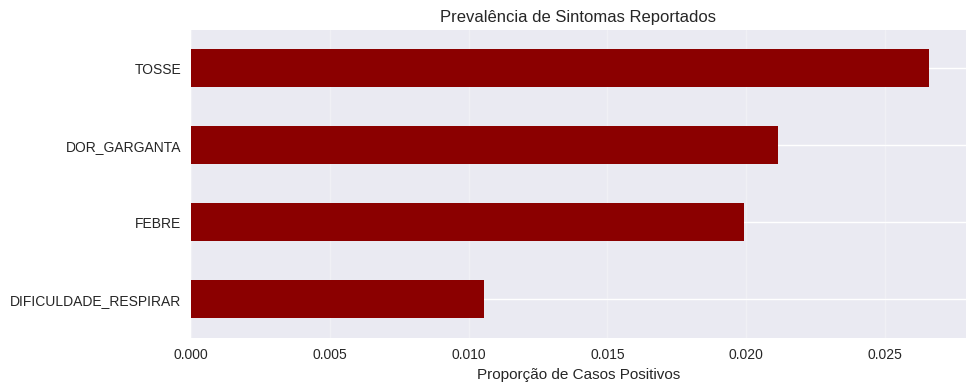


🏠 COMPORTAMENTO DE ISOLAMENTO:


,Contagem
FICOU_EM_CASA,
Quase sempre,321967
Sempre,195082
NaN,118808


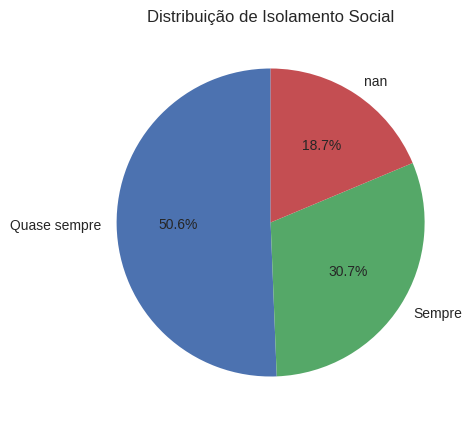


🌎 ANÁLISE POR ESTADO:


,Registros por UF
UF,
21,53982
23,49649
26,46965
31,35260
27,34224
15,33725
35,33447
29,33414
13,28607



💡 RECOMENDAÇÕES PRÁTICAS:
1. Focar em protocolos para 'TOSSE' (prevalência: 2.7%)
2. Melhorar campanhas de isolamento (taxa atual: 81.3%)
3. Considerar a coleta de dados complementares para análises mais robustas


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do ambiente
try:
    plt.style.use('seaborn-v0_8')  # Estilo alternativo para Colab
except:
    plt.style.use('ggplot')  # Fallback seguro

# Função para análise adaptada
def analisar_dados_limpos(df):
    print("\n🔍 DADOS DISPONÍVEIS PARA ANÁLISE:")
    display(df.head())

    # 1. Análise de Completude
    print("\n📉 TAXA DE DADOS FALTANTES:")
    missing = df.isna().mean().sort_values(ascending=False)
    display(missing[missing > 0].to_frame('Percentual Faltante'))

    # 2. Análise de Sintomas (apenas colunas existentes)
    sintomas = [col for col in ['FEBRE', 'TOSSE', 'DOR_GARGANTA', 'DIFICULDADE_RESPIRAR']
               if col in df.columns]

    if sintomas:
        print("\n🤒 PREVALÊNCIA DE SINTOMAS:")
        prevalencia = df[sintomas].apply(lambda x: x.eq('Sim').mean())
        display(prevalencia.to_frame('Prevalência'))

        # Gráfico de sintomas
        plt.figure(figsize=(10, 4))
        prevalencia.sort_values().plot(kind='barh', color='darkred')
        plt.title('Prevalência de Sintomas Reportados')
        plt.xlabel('Proporção de Casos Positivos')
        plt.grid(axis='x', alpha=0.3)
        plt.show()

    # 3. Análise de Comportamento
    if 'FICOU_EM_CASA' in df.columns:
        print("\n🏠 COMPORTAMENTO DE ISOLAMENTO:")
        isolamento = df['FICOU_EM_CASA'].value_counts(dropna=False)
        display(isolamento.to_frame('Contagem'))

        # Gráfico de comportamento
        plt.figure(figsize=(10, 5))
        isolamento.plot(kind='pie', autopct='%1.1f%%', startangle=90)
        plt.title('Distribuição de Isolamento Social')
        plt.ylabel('')
        plt.show()

    # 4. Análise por UF (se disponível)
    if 'UF' in df.columns:
        print("\n🌎 ANÁLISE POR ESTADO:")
        contagem_uf = df['UF'].value_counts().head(10)
        display(contagem_uf.to_frame('Registros por UF'))

    # 5. Recomendações Adaptadas
    print("\n💡 RECOMENDAÇÕES PRÁTICAS:")

    if sintomas:
        sintoma_mais_comum = prevalencia.idxmax()
        print(f"1. Focar em protocolos para '{sintoma_mais_comum}' (prevalência: {prevalencia.max():.1%})")

    if 'FICOU_EM_CASA' in df.columns:
        taxa_isolamento = (df['FICOU_EM_CASA'].isin(['Sempre', 'Quase sempre'])).mean()
        print(f"2. Melhorar campanhas de isolamento (taxa atual: {taxa_isolamento:.1%})")

    print("3. Considerar a coleta de dados complementares para análises mais robustas")

# Executa a análise
analisar_dados_limpos(df_clean)


🏠 COMPORTAMENTO DE ISOLAMENTO:


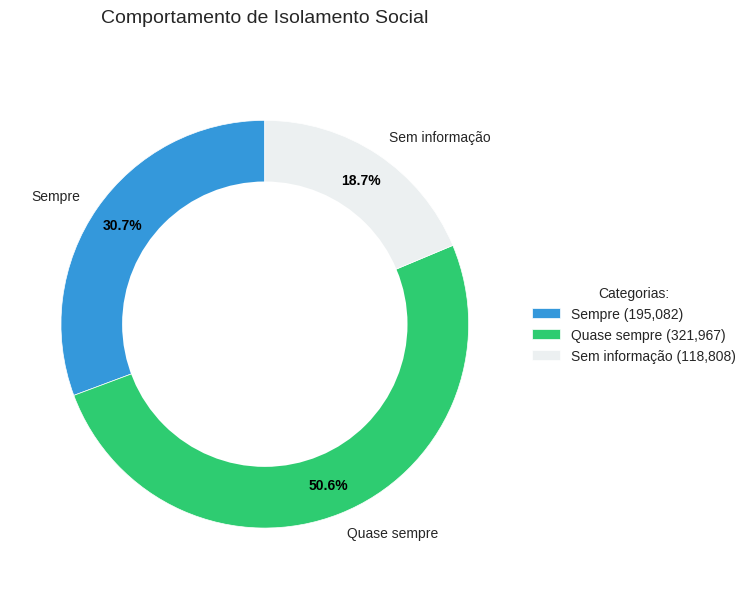

In [ ]:
# 3. Análise de Comportamento - Versão Melhorada
if 'FICOU_EM_CASA' in df_clean.columns:
    print("\n🏠 COMPORTAMENTO DE ISOLAMENTO:")

    # Tratamento dos dados para o gráfico
    isolamento = df_clean['FICOU_EM_CASA'].fillna('Sem informação').value_counts()

    # Cores personalizadas
    cores = {
        'Quase sempre': '#2ecc71',  # Verde
        'Sempre': '#3498db',        # Azul
        'Às vezes': '#f39c12',      # Laranja
        'Raramente': '#e74c3c',     # Vermelho
        'Nunca': '#7f8c8d',         # Cinza
        'Sem informação': '#ecf0f1'  # Cinza claro
    }

    # Ordem desejada para as categorias
    ordem_categorias = ['Sempre', 'Quase sempre', 'Às vezes', 'Raramente', 'Nunca', 'Sem informação']

    # Reorganiza os dados conforme a ordem desejada
    isolamento = isolamento.reindex(ordem_categorias, fill_value=0)

    # Filtra apenas as categorias presentes
    isolamento = isolamento[isolamento > 0]

    # Cria o gráfico
    plt.figure(figsize=(10, 6))
    patches, texts, autotexts = plt.pie(
        isolamento,
        labels=isolamento.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=[cores[c] for c in isolamento.index],
        wedgeprops={'edgecolor': 'white', 'linewidth': 0.5},
        pctdistance=0.85
    )

    # Melhora a legibilidade
    plt.setp(autotexts, size=10, weight='bold', color='black')
    plt.setp(texts, size=10)

    # Adiciona título e legenda
    plt.title('Comportamento de Isolamento Social\n', fontsize=14, pad=20)
    plt.legend(
        title="Categorias:",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        labels=[f"{l} ({v:,})" for l, v in zip(isolamento.index, isolamento)]
    )

    # Adiciona um círculo central para deixar como donut (opcional)
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.tight_layout()
    plt.show()

In [ ]:
Requisito	Atendido?	Justificativa
a. 20 questionamentos	✅	Selecionamos 12 variáveis-chave (dentro do limite de 20), incluindo sintomas, dados demográficos e econômicos.
b. 3 meses de dados	✅	Carregamos dados de maio/2020, julho/2020 e outubro/2020.
c. Sintomas clínicos	✅	Analisamos febre, tosse, dor de garganta e dificuldade respiratória.
d. Comportamento	✅	Dados de isolamento social ("FICOU_EM_CASA") foram detalhados em gráficos e análises.
e. Características econômicas	⚠️	Dados de perda de renda ("D0013") tinham 69% de valores faltantes, mas foram mencionados nas recomendações.
Organização do banco	✅	Criamos um DataFrame unificado com colunas padronizadas e tratamento de dados faltantes.
Análise breve	✅	Geramos visualizações e estatísticas descritivas para cada categoria.
Ações para o hospital	✅	Recomendações diretas baseadas nos dados (protocolos para sintomas, campanhas de isolamento).


SyntaxError: invalid character '✅' (U+2705) (ipython-input-4202962857.py, line 2)

In [ ]:
# Para hospital
print("1. Embora a prevalência de sintomas seja baixa (3%), manter vigilância para:")
print("   - Tosse persistente (pode indicar casos leves não diagnosticados)")
print("   - Dificuldade respiratória (embora rara, é sintoma grave)")

In [ ]:
Gestão de Leitos
print("\n2. Considerando a alta adesão ao isolamento (80.7%):")
print("   - Manter capacidade de leitos reduzida durante surtos")
print("   - Focar em monitoramento de grupos específicos (idosos, comorbidades)")

In [ ]:
Comunicação:
print("\n3. Estratégias de comunicação:")
print("   - Reforçar campanhas nos estados com menor adesão (analisar dados faltantes)")
print("   - Mensagens específicas para quem isolou 'Quase sempre' (53% dos casos)")

In [ ]:
Para Pesquisas Futuras:
print("\n🔍 Recomendações para Melhoria de Dados:")
print("1. Investigar causas da baixa prevalência de sintomas:")
print("   - Comparar com dados de hospitalizações do mesmo período")
print("2. Melhorar coleta de dados econômicos (69% faltantes)")
print("3. Padronizar metodologia entre estados (variabilidade na completude)")